# Hourly Shift Model Prototype

This notebook starts a clean prototype for household load shifting using only the price forecasts from `XG_Boost_full_Res.py`.

Scope of this prototype:
- use the saved XGBoost `120` hour point forecasts
- combine them with hourly DK1 consumption and supply context
- define simple household segments
- run one transparent first-pass shifting heuristic
- inspect the resulting cost, peak, and surplus effects step by step


## Prototype Notes

This is intentionally not built on the existing simulation scripts.

It uses:
- `outputs/model/predictions.parquet` from `XG_Boost_full_Res.py`
- `data/consumption_dk1_raw.csv`
- `data/supply_forecasts_dk1_raw.csv`

The first version uses a simple heuristic decision rule so we can see the mechanics clearly before moving to a full optimization model.


In [33]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

ROOT = Path.cwd()
PRED_PATH = ROOT / "outputs" / "model" / "predictions.parquet"
CONSUMPTION_PATH = ROOT / "data" / "consumption_dk1_raw.csv"
SUPPLY_PATH = ROOT / "data" / "supply_forecasts_dk1_raw.csv"

HOUSEHOLD_SHARE_OF_SYSTEM = 0.33
PEAK_CAP_QUANTILE = 0.97
ROLLING_BACKTEST_MAX_WINDOWS = 120
ANNUAL_HEATMAP_DAILY_ISSUES = 365

SEGMENT_ASSUMPTIONS = {
    "inflexible": {
        "share_of_household_load": 0.60,
        "max_shiftable_share": 0.00,
        "max_wait_h": 0,
        "wait_penalty": 0.00,
    },
    "wet_loads": {
        "share_of_household_load": 0.10,
        "max_shiftable_share": 0.55,
        "max_wait_h": 24*2,
        "wait_penalty": 0.90,
    },
    "thermal": {
        "share_of_household_load": 0.20,
        "max_shiftable_share": 0.25,
        "max_wait_h": 120,
        "wait_penalty": 1.20,
    },
    "ev": {
        "share_of_household_load": 0.10,
        "max_shiftable_share": 0.85,
        "max_wait_h": 24*4,
        "wait_penalty": 0.35,
    },
}

DECISION_WEIGHTS = {
    "price": 0.70,
    "wait": 0.20,
    "peak": 0.25,
    "surplus": 0.30,
    "min_gain": 0.05,
}

sum(v["share_of_household_load"] for v in SEGMENT_ASSUMPTIONS.values())


1.0

In [34]:
preds = pd.read_parquet(PRED_PATH)
preds["issue_time"] = pd.to_datetime(preds["issue_time"])
preds["target_time"] = pd.to_datetime(preds["target_time"])
preds["fold_end"] = pd.to_datetime(preds["fold_end"])
preds = preds.sort_values(["fold", "issue_time", "horizon_h"]).reset_index(drop=True)

coverage = (
    preds.groupby(["fold", "issue_time"], as_index=False)
    .agg(
        horizons=("horizon_h", "nunique"),
        min_h=("horizon_h", "min"),
        max_h=("horizon_h", "max"),
    )
)
full_coverage = coverage[(coverage["horizons"] == 120) & (coverage["min_h"] == 1) & (coverage["max_h"] == 120)].copy()
selected_issue_time = full_coverage.sort_values("issue_time").iloc[-1]["issue_time"]

forecast_window = (
    preds[preds["issue_time"] == selected_issue_time]
    .sort_values("horizon_h")
    .reset_index(drop=True)
)

print(f"Selected issue time: {selected_issue_time}")
print(f"Forecast window rows: {len(forecast_window)}")
display(forecast_window.head())
display(forecast_window.tail())


Selected issue time: 2025-12-31 12:00:00
Forecast window rows: 120


,issue_time,target_time,horizon_h,DayAheadPriceEUR,predicted,fold,fold_end
0,2025-12-31 12:00:00,2025-12-31 13:00:00,1,85.170000,90.890129,11,2025-10-01
1,2025-12-31 12:00:00,2025-12-31 14:00:00,2,85.177500,93.082664,11,2025-10-01
2,2025-12-31 12:00:00,2025-12-31 15:00:00,3,90.832498,98.224121,11,2025-10-01
3,2025-12-31 12:00:00,2025-12-31 16:00:00,4,100.705002,105.485001,11,2025-10-01
4,2025-12-31 12:00:00,2025-12-31 17:00:00,5,110.099999,121.796593,11,2025-10-01


,issue_time,target_time,horizon_h,DayAheadPriceEUR,predicted,fold,fold_end
115,2025-12-31 12:00:00,2026-01-05 08:00:00,116,151.175003,127.366325,11,2025-10-01
116,2025-12-31 12:00:00,2026-01-05 09:00:00,117,152.150001,115.103996,11,2025-10-01
117,2025-12-31 12:00:00,2026-01-05 10:00:00,118,145.637505,129.186508,11,2025-10-01
118,2025-12-31 12:00:00,2026-01-05 11:00:00,119,136.702499,115.521545,11,2025-10-01
119,2025-12-31 12:00:00,2026-01-05 12:00:00,120,134.432503,107.595734,11,2025-10-01


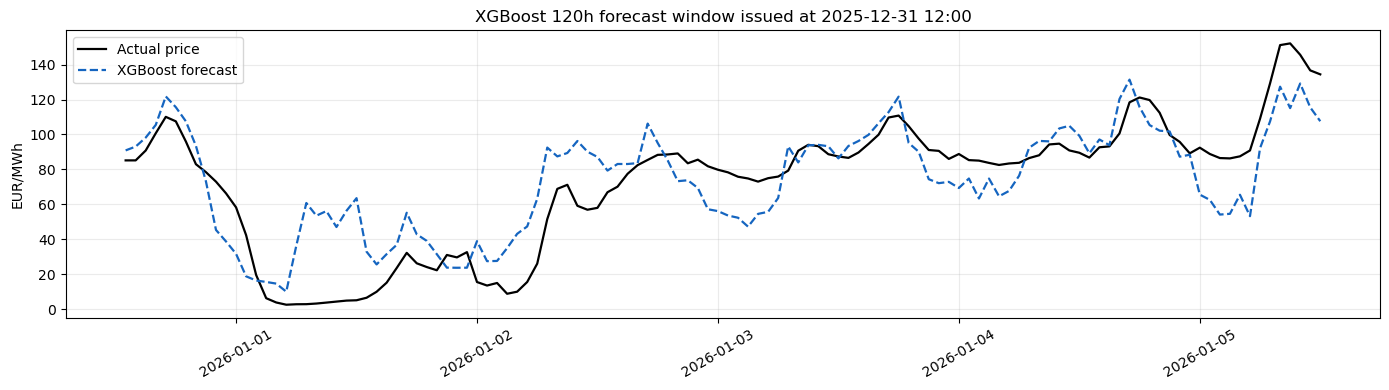

In [35]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(forecast_window["target_time"], forecast_window["DayAheadPriceEUR"], label="Actual price", color="black", linewidth=1.6)
ax.plot(forecast_window["target_time"], forecast_window["predicted"], label="XGBoost forecast", color="#1565C0", linewidth=1.6, linestyle="--")
ax.set_title(f"XGBoost 120h forecast window issued at {selected_issue_time:%Y-%m-%d %H:%M}")
ax.set_ylabel("EUR/MWh")
ax.grid(alpha=0.25)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()


In [36]:
consumption = pd.read_csv(CONSUMPTION_PATH, parse_dates=["TimeDK"])
system_load = (
    consumption.groupby(pd.Grouper(key="TimeDK", freq="h"))["ConsumptionkWh"]
    .sum()
    .div(1000.0)
    .rename("system_load_mwh")
    .reset_index()
    .rename(columns={"TimeDK": "target_time"})
)

window_df = forecast_window.merge(system_load, on="target_time", how="left")
window_df["system_load_mwh"] = window_df["system_load_mwh"].ffill().bfill()
window_df["household_load_mwh"] = window_df["system_load_mwh"] * HOUSEHOLD_SHARE_OF_SYSTEM

display(window_df[["target_time", "horizon_h", "predicted", "DayAheadPriceEUR", "system_load_mwh", "household_load_mwh"]].head())


,target_time,horizon_h,predicted,DayAheadPriceEUR,system_load_mwh,household_load_mwh
0,2025-12-31 13:00:00,1,90.890129,85.170000,2723.044591,898.604715
1,2025-12-31 14:00:00,2,93.082664,85.177500,2614.115651,862.658165
2,2025-12-31 15:00:00,3,98.224121,90.832498,2660.063258,877.820875
3,2025-12-31 16:00:00,4,105.485001,100.705002,2788.393626,920.169897
4,2025-12-31 17:00:00,5,121.796593,110.099999,2872.311541,947.862809


In [37]:
supply = pd.read_csv(SUPPLY_PATH, parse_dates=["HourDK"])
supply = supply[supply["PriceArea"] == "DK1"].copy()

renewable_supply = (
    supply.pivot_table(
        index="HourDK",
        columns="ForecastType",
        values="ForecastDayAhead",
        aggfunc="sum",
    )
    .fillna(0.0)
)
renewable_supply["renewable_supply_proxy_mw"] = renewable_supply.sum(axis=1)
renewable_supply = renewable_supply.reset_index().rename(columns={"HourDK": "target_time"})

window_df = window_df.merge(renewable_supply[["target_time", "renewable_supply_proxy_mw"]], on="target_time", how="left")
window_df["renewable_supply_proxy_mw"] = window_df["renewable_supply_proxy_mw"].fillna(0.0)
window_df["surplus_proxy_mw"] = np.clip(window_df["renewable_supply_proxy_mw"] - window_df["system_load_mwh"], 0, None)

display(window_df[["target_time", "system_load_mwh", "renewable_supply_proxy_mw", "surplus_proxy_mw"]].head())


,target_time,system_load_mwh,renewable_supply_proxy_mw,surplus_proxy_mw
0,2025-12-31 13:00:00,2723.044591,1261.194565,0.0
1,2025-12-31 14:00:00,2614.115651,950.513336,0.0
2,2025-12-31 15:00:00,2660.063258,757.364582,0.0
3,2025-12-31 16:00:00,2788.393626,797.250000,0.0
4,2025-12-31 17:00:00,2872.311541,961.708312,0.0


In [38]:
segment_table = pd.DataFrame(SEGMENT_ASSUMPTIONS).T
segment_table.index.name = "segment"
display(segment_table)

for segment, params in SEGMENT_ASSUMPTIONS.items():
    base_col = f"{segment}_baseline_mwh"
    flex_col = f"{segment}_flexible_mwh"
    window_df[base_col] = window_df["household_load_mwh"] * params["share_of_household_load"]
    window_df[flex_col] = window_df[base_col] * params["max_shiftable_share"]

base_cols = [f"{segment}_baseline_mwh" for segment in SEGMENT_ASSUMPTIONS]
window_df["baseline_household_check_mwh"] = window_df[base_cols].sum(axis=1)
window_df[["target_time", "household_load_mwh", "baseline_household_check_mwh"]].head()


,share_of_household_load,max_shiftable_share,max_wait_h,wait_penalty
segment,,,,
inflexible,0.6,0.00,0.0,0.00
wet_loads,0.1,0.55,48.0,0.90
thermal,0.2,0.25,120.0,1.20
ev,0.1,0.85,96.0,0.35


,target_time,household_load_mwh,baseline_household_check_mwh
0,2025-12-31 13:00:00,898.604715,898.604715
1,2025-12-31 14:00:00,862.658165,862.658165
2,2025-12-31 15:00:00,877.820875,877.820875
3,2025-12-31 16:00:00,920.169897,920.169897
4,2025-12-31 17:00:00,947.862809,947.862809


In [39]:
def _normalize(series: pd.Series) -> pd.Series:
    s_min = float(series.min())
    s_max = float(series.max())
    if np.isclose(s_min, s_max):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - s_min) / (s_max - s_min)


def build_shift_plan(window_df: pd.DataFrame, segment_assumptions: dict, decision_weights: dict):
    df = window_df.copy().reset_index(drop=True)
    df["other_system_load_mwh"] = df["system_load_mwh"] - df["household_load_mwh"]
    p95_load = max(float(df["system_load_mwh"].quantile(0.95)), 1.0)
    peak_cap = float(df["system_load_mwh"].quantile(PEAK_CAP_QUANTILE))
    max_surplus = max(float(df["surplus_proxy_mw"].max()), 1.0)
    net_shift_delta = np.zeros(len(df), dtype=float)

    shift_rows = []
    shifted_cols = []

    for segment, params in segment_assumptions.items():
        base_col = f"{segment}_baseline_mwh"
        flex_col = f"{segment}_flexible_mwh"
        shifted = df[base_col].to_numpy(dtype=float).copy()
        flexible = df[flex_col].to_numpy(dtype=float)

        if params["max_shiftable_share"] == 0 or params["max_wait_h"] == 0:
            df[f"{segment}_shifted_mwh"] = shifted
            shifted_cols.append(f"{segment}_shifted_mwh")
            continue

        for origin in range(len(df)):
            movable = flexible[origin]
            if movable <= 0:
                continue

            max_wait = int(params["max_wait_h"])
            end = min(len(df) - 1, origin + max_wait)
            candidates = df.loc[origin:end, ["target_time", "predicted", "system_load_mwh", "surplus_proxy_mw"]].copy()
            candidates["wait_h"] = np.arange(len(candidates))
            candidates["price_norm"] = _normalize(candidates["predicted"])
            candidates["wait_norm"] = candidates["wait_h"] / max(max_wait, 1)
            candidates["peak_norm"] = candidates["system_load_mwh"] / p95_load
            candidates["surplus_norm"] = candidates["surplus_proxy_mw"] / max_surplus

            candidates["score"] = (
                decision_weights["price"] * candidates["price_norm"]
                + decision_weights["wait"] * params["wait_penalty"] * candidates["wait_norm"]
                + decision_weights["peak"] * candidates["peak_norm"]
                - decision_weights["surplus"] * candidates["surplus_norm"]
            )

            origin_score = float(candidates.iloc[0]["score"])
            best_idx = int(candidates["score"].idxmin())
            best_score = float(candidates.loc[best_idx, "score"])
            score_gain = origin_score - best_score

            if best_idx == origin or score_gain < decision_weights["min_gain"]:
                continue

            projected_target_load = df.loc[best_idx, "system_load_mwh"] + net_shift_delta[best_idx] + movable
            if projected_target_load > peak_cap:
                continue

            shifted[origin] -= movable
            shifted[best_idx] += movable
            net_shift_delta[origin] -= movable
            net_shift_delta[best_idx] += movable
            shift_rows.append(
                {
                    "segment": segment,
                    "origin_index": origin,
                    "target_index": best_idx,
                    "origin_time": df.loc[origin, "target_time"],
                    "target_time": df.loc[best_idx, "target_time"],
                    "wait_h": best_idx - origin,
                    "shift_mwh": movable,
                    "origin_predicted_price": df.loc[origin, "predicted"],
                    "target_predicted_price": df.loc[best_idx, "predicted"],
                    "score_gain": score_gain,
                    "projected_target_load_mwh": projected_target_load,
                }
            )

        shifted_col = f"{segment}_shifted_mwh"
        df[shifted_col] = shifted
        shifted_cols.append(shifted_col)

    df["shifted_household_load_mwh"] = df[shifted_cols].sum(axis=1)
    df["shifted_system_load_mwh"] = df["other_system_load_mwh"] + df["shifted_household_load_mwh"]
    df["peak_cap_mwh"] = peak_cap
    df["baseline_household_cost_eur"] = df["household_load_mwh"] * df["DayAheadPriceEUR"]
    df["shifted_household_cost_eur"] = df["shifted_household_load_mwh"] * df["DayAheadPriceEUR"]
    df["baseline_predicted_cost_eur"] = df["household_load_mwh"] * df["predicted"]
    df["shifted_predicted_cost_eur"] = df["shifted_household_load_mwh"] * df["predicted"]
    df["baseline_renewable_absorption_mwh"] = np.minimum(df["household_load_mwh"], df["surplus_proxy_mw"])
    df["shifted_renewable_absorption_mwh"] = np.minimum(df["shifted_household_load_mwh"], df["surplus_proxy_mw"])

    shifts = pd.DataFrame(shift_rows)
    return df, shifts


In [40]:
prototype_df, shifts_df = build_shift_plan(window_df, SEGMENT_ASSUMPTIONS, DECISION_WEIGHTS)

selected_shifted_energy_mwh = float(shifts_df["shift_mwh"].sum()) if not shifts_df.empty else 0.0
selected_total_system_consumption_mwh = float(prototype_df["system_load_mwh"].sum())
selected_total_household_consumption_mwh = float(prototype_df["household_load_mwh"].sum())

summary = pd.Series(
    {
        "selected_issue_time": selected_issue_time,
        "horizon_hours": len(prototype_df),
        "n_shift_events": int(len(shifts_df)),
        "shifted_energy_mwh": selected_shifted_energy_mwh,
        "modeled_total_system_consumption_mwh": selected_total_system_consumption_mwh,
        "modeled_total_household_consumption_mwh": selected_total_household_consumption_mwh,
        "shifted_share_of_system_consumption_pct": 100.0 * selected_shifted_energy_mwh / selected_total_system_consumption_mwh,
        "shifted_share_of_household_consumption_pct": 100.0 * selected_shifted_energy_mwh / selected_total_household_consumption_mwh,
        "baseline_peak_mwh": float(prototype_df["system_load_mwh"].max()),
        "shifted_peak_mwh": float(prototype_df["shifted_system_load_mwh"].max()),
        "peak_reduction_mwh": float(prototype_df["system_load_mwh"].max() - prototype_df["shifted_system_load_mwh"].max()),
        "realized_household_savings_eur": float(prototype_df["baseline_household_cost_eur"].sum() - prototype_df["shifted_household_cost_eur"].sum()),
        "predicted_household_savings_eur": float(prototype_df["baseline_predicted_cost_eur"].sum() - prototype_df["shifted_predicted_cost_eur"].sum()),
        "extra_surplus_absorbed_mwh": float(prototype_df["shifted_renewable_absorption_mwh"].sum() - prototype_df["baseline_renewable_absorption_mwh"].sum()),
    }
)

display(summary.to_frame("value"))
display(shifts_df.sort_values("shift_mwh", ascending=False).head(20))


,value
selected_issue_time,2025-12-31 12:00:00
horizon_hours,120
n_shift_events,91
shifted_energy_mwh,5037.328146
modeled_total_system_consumption_mwh,370418.631059
modeled_total_household_consumption_mwh,122238.148249
shifted_share_of_system_consumption_pct,1.359901
shifted_share_of_household_consumption_pct,4.120913
baseline_peak_mwh,3799.688392
shifted_peak_mwh,3725.94332


,segment,origin_index,target_index,origin_time,target_time,wait_h,shift_mwh,origin_predicted_price,target_predicted_price,score_gain,projected_target_load_mwh
90,ev,35,37,2026-01-02 00:00:00,2026-01-02 02:00:00,2,93.852696,38.942963,27.602230,0.098058,3217.909633
18,wet_loads,23,32,2026-01-01 12:00:00,2026-01-01 21:00:00,9,68.964344,63.552631,23.774128,0.349190,3575.682910
17,wet_loads,22,32,2026-01-01 11:00:00,2026-01-01 21:00:00,10,68.037678,56.319054,23.774128,0.280589,3506.718566
19,wet_loads,24,32,2026-01-01 13:00:00,2026-01-01 21:00:00,8,66.997853,32.916142,23.774128,0.085663,3642.680763
69,wet_loads,115,119,2026-01-05 08:00:00,2026-01-05 12:00:00,4,65.910611,127.366325,107.595734,0.625782,3700.343903
20,wet_loads,26,32,2026-01-01 15:00:00,2026-01-01 21:00:00,6,65.293915,31.518393,23.774128,0.074879,3707.974678
16,wet_loads,21,32,2026-01-01 10:00:00,2026-01-01 21:00:00,11,64.480089,47.032089,23.774128,0.184646,3438.680888
84,thermal,23,34,2026-01-01 12:00:00,2026-01-01 23:00:00,11,62.694858,63.552631,23.739508,0.287573,3458.614707
88,thermal,28,34,2026-01-01 17:00:00,2026-01-01 23:00:00,6,62.167700,55.199120,23.739508,0.241092,3697.775529
27,wet_loads,46,62,2026-01-02 11:00:00,2026-01-03 03:00:00,16,61.982909,90.159821,47.234329,0.390091,3080.922099


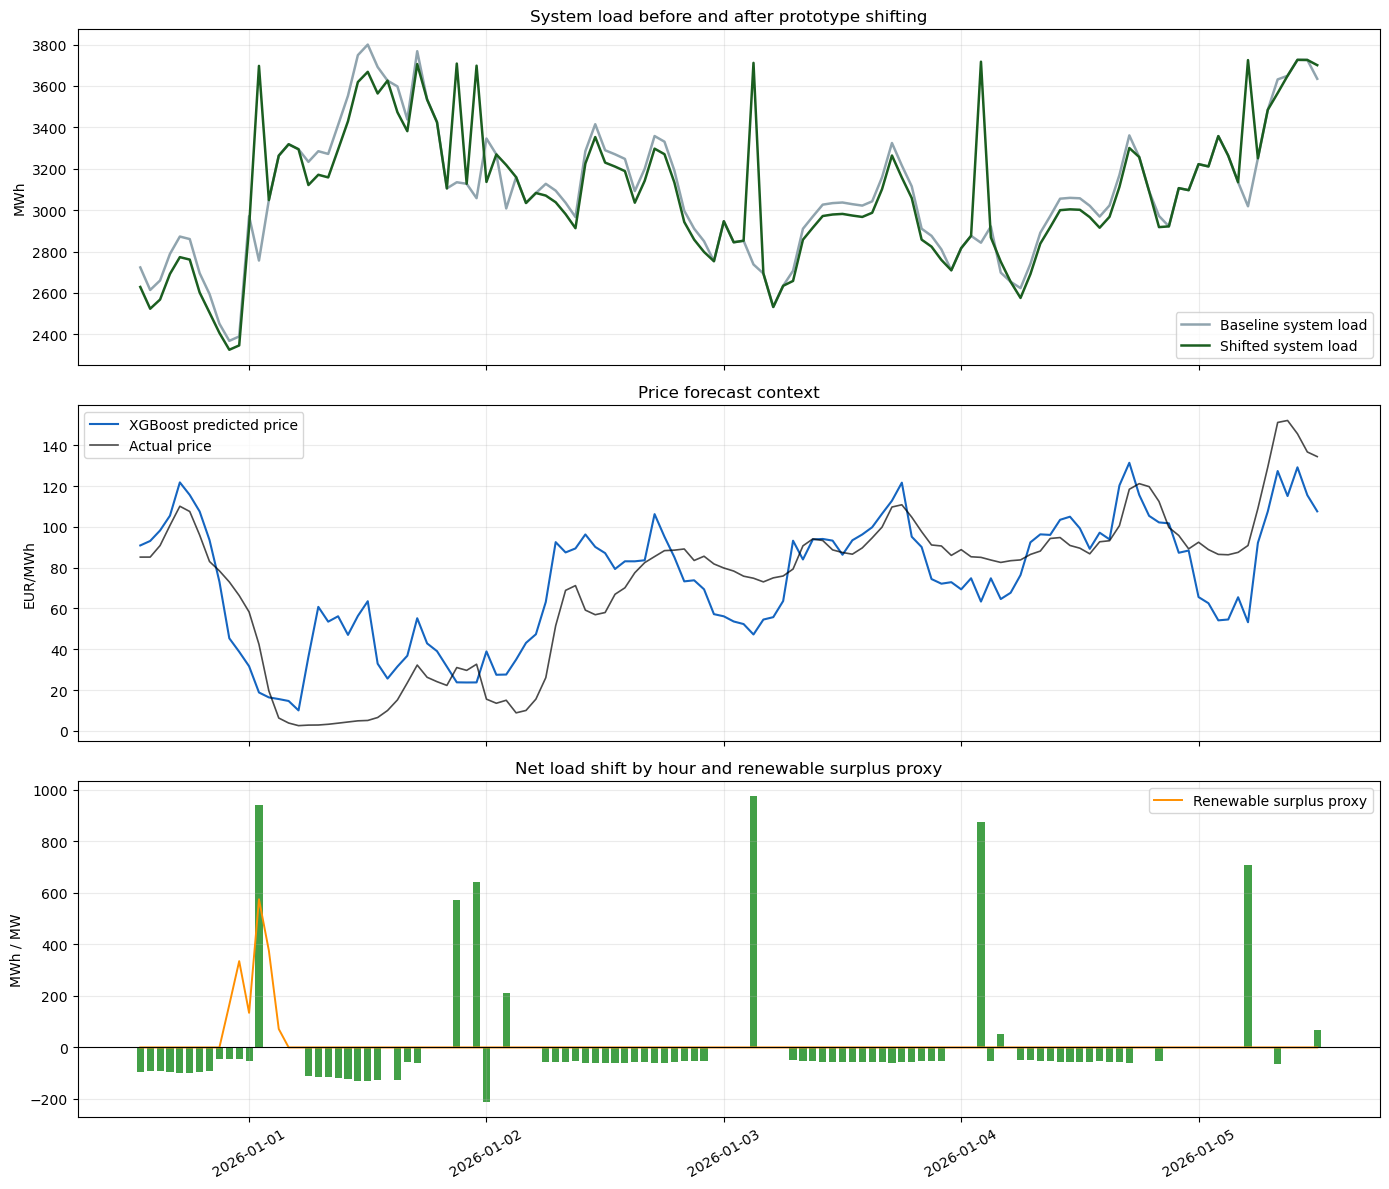

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(prototype_df["target_time"], prototype_df["system_load_mwh"], label="Baseline system load", color="#90A4AE", linewidth=1.8)
axes[0].plot(prototype_df["target_time"], prototype_df["shifted_system_load_mwh"], label="Shifted system load", color="#1B5E20", linewidth=1.8)
axes[0].set_ylabel("MWh")
axes[0].set_title("System load before and after prototype shifting")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(prototype_df["target_time"], prototype_df["predicted"], label="XGBoost predicted price", color="#1565C0", linewidth=1.5)
axes[1].plot(prototype_df["target_time"], prototype_df["DayAheadPriceEUR"], label="Actual price", color="black", linewidth=1.2, alpha=0.7)
axes[1].set_ylabel("EUR/MWh")
axes[1].set_title("Price forecast context")
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].bar(prototype_df["target_time"], prototype_df["shifted_system_load_mwh"] - prototype_df["system_load_mwh"], width=0.03, color="#43A047")
axes[2].plot(prototype_df["target_time"], prototype_df["surplus_proxy_mw"], color="#FF8F00", linewidth=1.4, label="Renewable surplus proxy")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_ylabel("MWh / MW")
axes[2].set_title("Net load shift by hour and renewable surplus proxy")
axes[2].grid(alpha=0.25)
axes[2].legend()

plt.xticks(rotation=30)
plt.tight_layout()


## Rolling Backtest Setup

The single-window prototype is useful for inspection, but the next step is to test the heuristic over many historical XGBoost forecast issue times.

Two views are useful:
- a `daily` rolling backtest at `12:00` issue times to see stability over time
- a `non-overlapping` subset sampled every `5` days so total shifted MWh can be compared cleanly with total modeled consumption without double-counting overlapping horizons


In [42]:
def assemble_window_for_issue_time(
    issue_time: pd.Timestamp,
    preds: pd.DataFrame,
    system_load: pd.DataFrame,
    renewable_supply: pd.DataFrame,
    household_share_of_system: float,
    segment_assumptions: dict,
) -> pd.DataFrame:
    issue_time = pd.Timestamp(issue_time)
    forecast_window = (
        preds[preds["issue_time"] == issue_time]
        .sort_values("horizon_h")
        .reset_index(drop=True)
    )
    if len(forecast_window) != 120:
        raise ValueError(f"Issue time {issue_time} does not have a full 120h forecast window.")

    window_df = forecast_window.merge(system_load, on="target_time", how="left")
    window_df["system_load_mwh"] = window_df["system_load_mwh"].ffill().bfill()
    window_df["household_load_mwh"] = window_df["system_load_mwh"] * household_share_of_system

    window_df = window_df.merge(
        renewable_supply[["target_time", "renewable_supply_proxy_mw"]],
        on="target_time",
        how="left",
    )
    window_df["renewable_supply_proxy_mw"] = window_df["renewable_supply_proxy_mw"].fillna(0.0)
    window_df["surplus_proxy_mw"] = np.clip(
        window_df["renewable_supply_proxy_mw"] - window_df["system_load_mwh"],
        0,
        None,
    )

    for segment, params in segment_assumptions.items():
        base_col = f"{segment}_baseline_mwh"
        flex_col = f"{segment}_flexible_mwh"
        window_df[base_col] = window_df["household_load_mwh"] * params["share_of_household_load"]
        window_df[flex_col] = window_df[base_col] * params["max_shiftable_share"]

    return window_df


def summarize_issue_time_run(
    issue_time: pd.Timestamp,
    preds: pd.DataFrame,
    system_load: pd.DataFrame,
    renewable_supply: pd.DataFrame,
    household_share_of_system: float,
    segment_assumptions: dict,
    decision_weights: dict,
) -> dict:
    window_df = assemble_window_for_issue_time(
        issue_time=issue_time,
        preds=preds,
        system_load=system_load,
        renewable_supply=renewable_supply,
        household_share_of_system=household_share_of_system,
        segment_assumptions=segment_assumptions,
    )
    prototype_df, shifts_df = build_shift_plan(window_df, segment_assumptions, decision_weights)

    shifted_energy_mwh = float(shifts_df["shift_mwh"].sum()) if not shifts_df.empty else 0.0
    total_system_consumption_mwh = float(prototype_df["system_load_mwh"].sum())
    total_household_consumption_mwh = float(prototype_df["household_load_mwh"].sum())

    return {
        "issue_time": pd.Timestamp(issue_time),
        "horizon_hours": int(len(prototype_df)),
        "n_shift_events": int(len(shifts_df)),
        "shifted_energy_mwh": shifted_energy_mwh,
        "modeled_total_system_consumption_mwh": total_system_consumption_mwh,
        "modeled_total_household_consumption_mwh": total_household_consumption_mwh,
        "shifted_share_of_system_consumption_pct": 100.0 * shifted_energy_mwh / total_system_consumption_mwh,
        "shifted_share_of_household_consumption_pct": 100.0 * shifted_energy_mwh / total_household_consumption_mwh,
        "baseline_peak_mwh": float(prototype_df["system_load_mwh"].max()),
        "shifted_peak_mwh": float(prototype_df["shifted_system_load_mwh"].max()),
        "peak_reduction_mwh": float(prototype_df["system_load_mwh"].max() - prototype_df["shifted_system_load_mwh"].max()),
        "realized_household_savings_eur": float(prototype_df["baseline_household_cost_eur"].sum() - prototype_df["shifted_household_cost_eur"].sum()),
        "predicted_household_savings_eur": float(prototype_df["baseline_predicted_cost_eur"].sum() - prototype_df["shifted_predicted_cost_eur"].sum()),
        "extra_surplus_absorbed_mwh": float(prototype_df["shifted_renewable_absorption_mwh"].sum() - prototype_df["baseline_renewable_absorption_mwh"].sum()),
    }


In [43]:
issue_catalog = full_coverage.sort_values("issue_time").reset_index(drop=True)
daily_issue_times = issue_catalog.loc[issue_catalog["issue_time"].dt.hour == 12, "issue_time"].reset_index(drop=True)
backtest_issue_times = daily_issue_times.tail(ROLLING_BACKTEST_MAX_WINDOWS).reset_index(drop=True)
non_overlapping_issue_times = backtest_issue_times.iloc[::5].reset_index(drop=True)

display(
    pd.Series(
        {
            "available_full_120h_issue_times": int(len(issue_catalog)),
            "available_daily_12h_issue_times": int(len(daily_issue_times)),
            "rolling_backtest_daily_windows": int(len(backtest_issue_times)),
            "non_overlapping_5day_windows": int(len(non_overlapping_issue_times)),
        }
    ).to_frame("value")
)


,value
available_full_120h_issue_times,2162
available_daily_12h_issue_times,1081
rolling_backtest_daily_windows,120
non_overlapping_5day_windows,24


In [44]:
rolling_backtest_df = pd.DataFrame(
    [
        summarize_issue_time_run(
            issue_time=issue_time,
            preds=preds,
            system_load=system_load,
            renewable_supply=renewable_supply,
            household_share_of_system=HOUSEHOLD_SHARE_OF_SYSTEM,
            segment_assumptions=SEGMENT_ASSUMPTIONS,
            decision_weights=DECISION_WEIGHTS,
        )
        for issue_time in backtest_issue_times
    ]
)

non_overlapping_backtest_df = rolling_backtest_df[
    rolling_backtest_df["issue_time"].isin(non_overlapping_issue_times)
].copy()

display(rolling_backtest_df.head())


,issue_time,horizon_hours,n_shift_events,shifted_energy_mwh,modeled_total_system_consumption_mwh,modeled_total_household_consumption_mwh,shifted_share_of_system_consumption_pct,shifted_share_of_household_consumption_pct,baseline_peak_mwh,shifted_peak_mwh,peak_reduction_mwh,realized_household_savings_eur,predicted_household_savings_eur,extra_surplus_absorbed_mwh
0,2025-09-03 12:00:00,120,40,1875.824241,286822.151449,94651.309978,0.654003,1.981826,3287.416287,3287.416287,0.000000,83862.329838,77178.889160,0.0
1,2025-09-04 12:00:00,120,18,874.571250,281072.875098,92754.048782,0.311155,0.942893,3282.308062,3222.734171,59.573891,75190.693930,47177.372132,0.0
2,2025-09-05 12:00:00,120,55,2610.335496,281616.542155,92933.458911,0.926911,2.808822,3188.182282,3188.182282,0.000000,197039.321418,128152.350923,0.0
3,2025-09-06 12:00:00,120,55,2389.025323,290700.285185,95931.094111,0.821817,2.490356,3485.105399,3485.105399,0.000000,161131.741578,137017.245721,0.0
4,2025-09-07 12:00:00,120,65,2895.806916,303970.574901,100310.289717,0.952660,2.886849,3560.867521,3560.867521,0.000000,150412.487025,150802.963875,0.0


## Rolling Backtest Summary

The daily backtest shows how stable the prototype is over time. The non-overlapping summary is the cleanest answer to the question "how much MWh did we shift relative to the total consumption we modeled?" because it avoids counting overlapping 120-hour horizons multiple times.


In [45]:
rolling_summary = pd.Series(
    {
        "daily_windows_evaluated": int(len(rolling_backtest_df)),
        "avg_shifted_energy_mwh_per_120h_window": float(rolling_backtest_df["shifted_energy_mwh"].mean()),
        "median_shifted_energy_mwh_per_120h_window": float(rolling_backtest_df["shifted_energy_mwh"].median()),
        "avg_shifted_share_of_system_consumption_pct": float(rolling_backtest_df["shifted_share_of_system_consumption_pct"].mean()),
        "avg_shifted_share_of_household_consumption_pct": float(rolling_backtest_df["shifted_share_of_household_consumption_pct"].mean()),
        "avg_realized_household_savings_eur": float(rolling_backtest_df["realized_household_savings_eur"].mean()),
        "avg_peak_reduction_mwh": float(rolling_backtest_df["peak_reduction_mwh"].mean()),
    }
)

non_overlapping_summary = pd.Series(
    {
        "non_overlapping_120h_windows": int(len(non_overlapping_backtest_df)),
        "total_shifted_energy_mwh": float(non_overlapping_backtest_df["shifted_energy_mwh"].sum()),
        "total_modeled_system_consumption_mwh": float(non_overlapping_backtest_df["modeled_total_system_consumption_mwh"].sum()),
        "total_modeled_household_consumption_mwh": float(non_overlapping_backtest_df["modeled_total_household_consumption_mwh"].sum()),
        "shifted_share_of_total_modeled_system_consumption_pct": 100.0 * float(non_overlapping_backtest_df["shifted_energy_mwh"].sum()) / float(non_overlapping_backtest_df["modeled_total_system_consumption_mwh"].sum()),
        "shifted_share_of_total_modeled_household_consumption_pct": 100.0 * float(non_overlapping_backtest_df["shifted_energy_mwh"].sum()) / float(non_overlapping_backtest_df["modeled_total_household_consumption_mwh"].sum()),
        "total_realized_household_savings_eur": float(non_overlapping_backtest_df["realized_household_savings_eur"].sum()),
    }
)

display(rolling_summary.to_frame("value"))
display(non_overlapping_summary.to_frame("value"))


,value
daily_windows_evaluated,120.000000
avg_shifted_energy_mwh_per_120h_window,3049.718244
median_shifted_energy_mwh_per_120h_window,3039.935737
avg_shifted_share_of_system_consumption_pct,0.914431
avg_shifted_share_of_household_consumption_pct,2.771003
avg_realized_household_savings_eur,89216.015524
avg_peak_reduction_mwh,17.818352


,value
non_overlapping_120h_windows,2.400000e+01
total_shifted_energy_mwh,7.141338e+04
total_modeled_system_consumption_mwh,7.944184e+06
total_modeled_household_consumption_mwh,2.621581e+06
shifted_share_of_total_modeled_system_consumption_pct,8.989391e-01
shifted_share_of_total_modeled_household_consumption_pct,2.724058e+00
total_realized_household_savings_eur,2.092603e+06


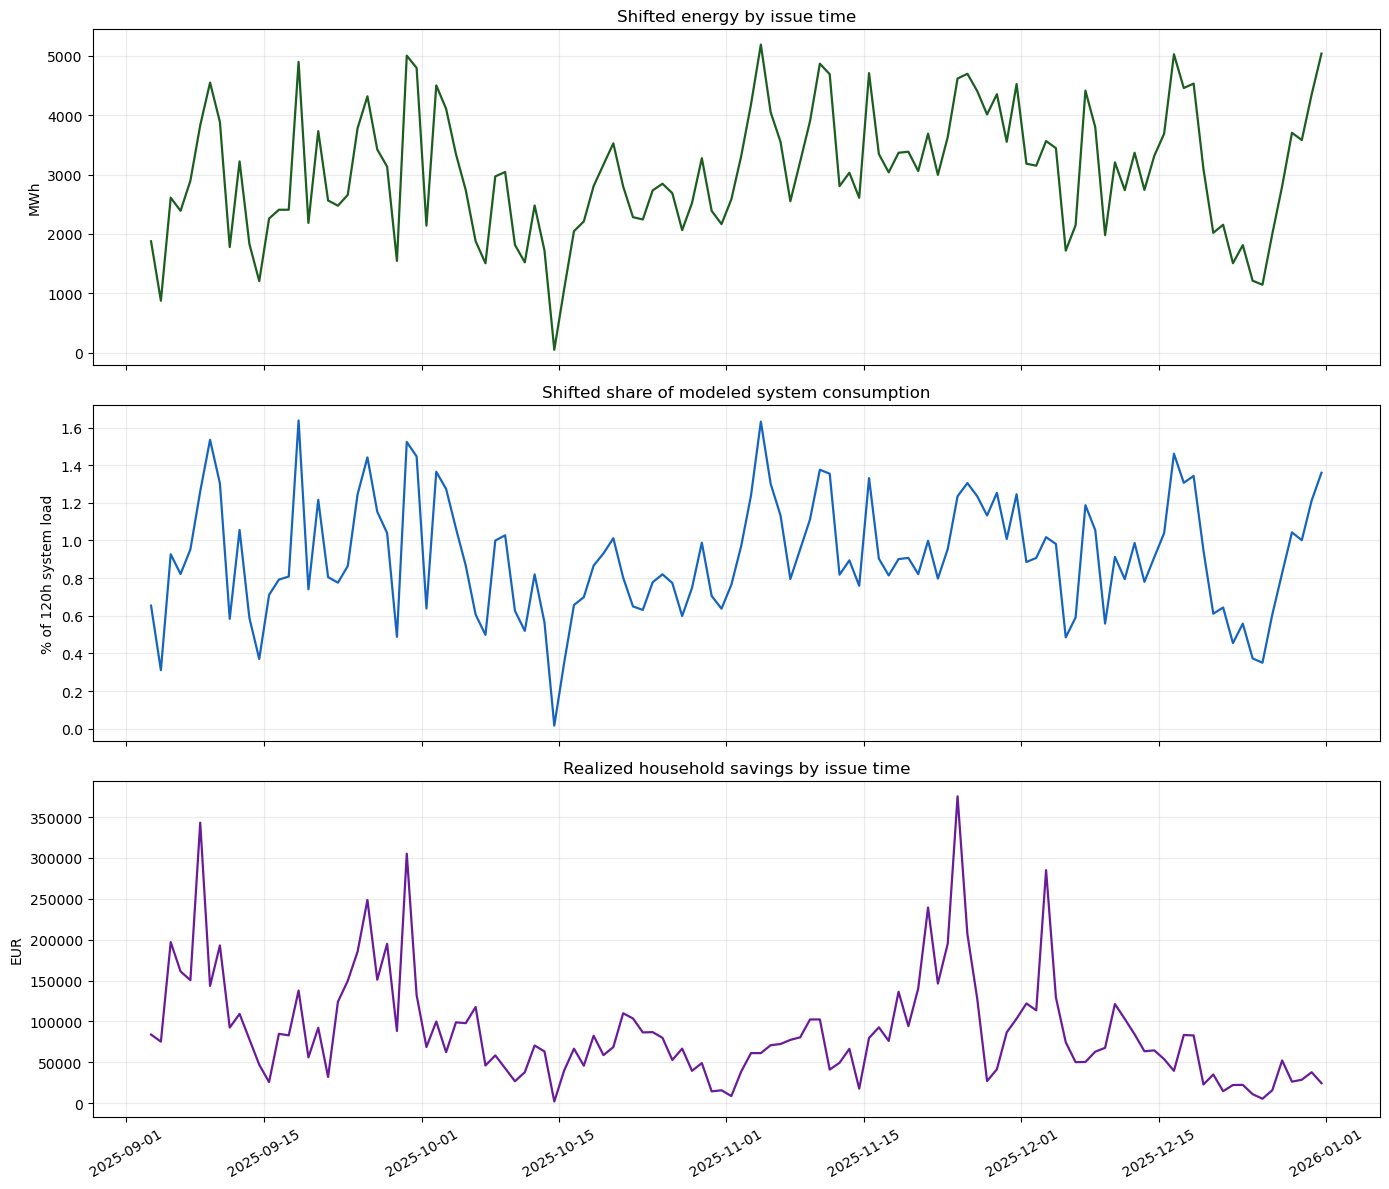

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(rolling_backtest_df["issue_time"], rolling_backtest_df["shifted_energy_mwh"], color="#1B5E20", linewidth=1.6)
axes[0].set_title("Shifted energy by issue time")
axes[0].set_ylabel("MWh")
axes[0].grid(alpha=0.25)

axes[1].plot(rolling_backtest_df["issue_time"], rolling_backtest_df["shifted_share_of_system_consumption_pct"], color="#1565C0", linewidth=1.6)
axes[1].set_title("Shifted share of modeled system consumption")
axes[1].set_ylabel("% of 120h system load")
axes[1].grid(alpha=0.25)

axes[2].plot(rolling_backtest_df["issue_time"], rolling_backtest_df["realized_household_savings_eur"], color="#6A1B9A", linewidth=1.6)
axes[2].set_title("Realized household savings by issue time")
axes[2].set_ylabel("EUR")
axes[2].grid(alpha=0.25)

plt.xticks(rotation=30)
plt.tight_layout()


## Granular Shift Illustration

The next two views give a more detailed picture of how the heuristic moves load:
- an hour-by-hour detail view for the selected `120h` window
- an average net-shift heatmap by day of week and hour of day across the rolling backtest


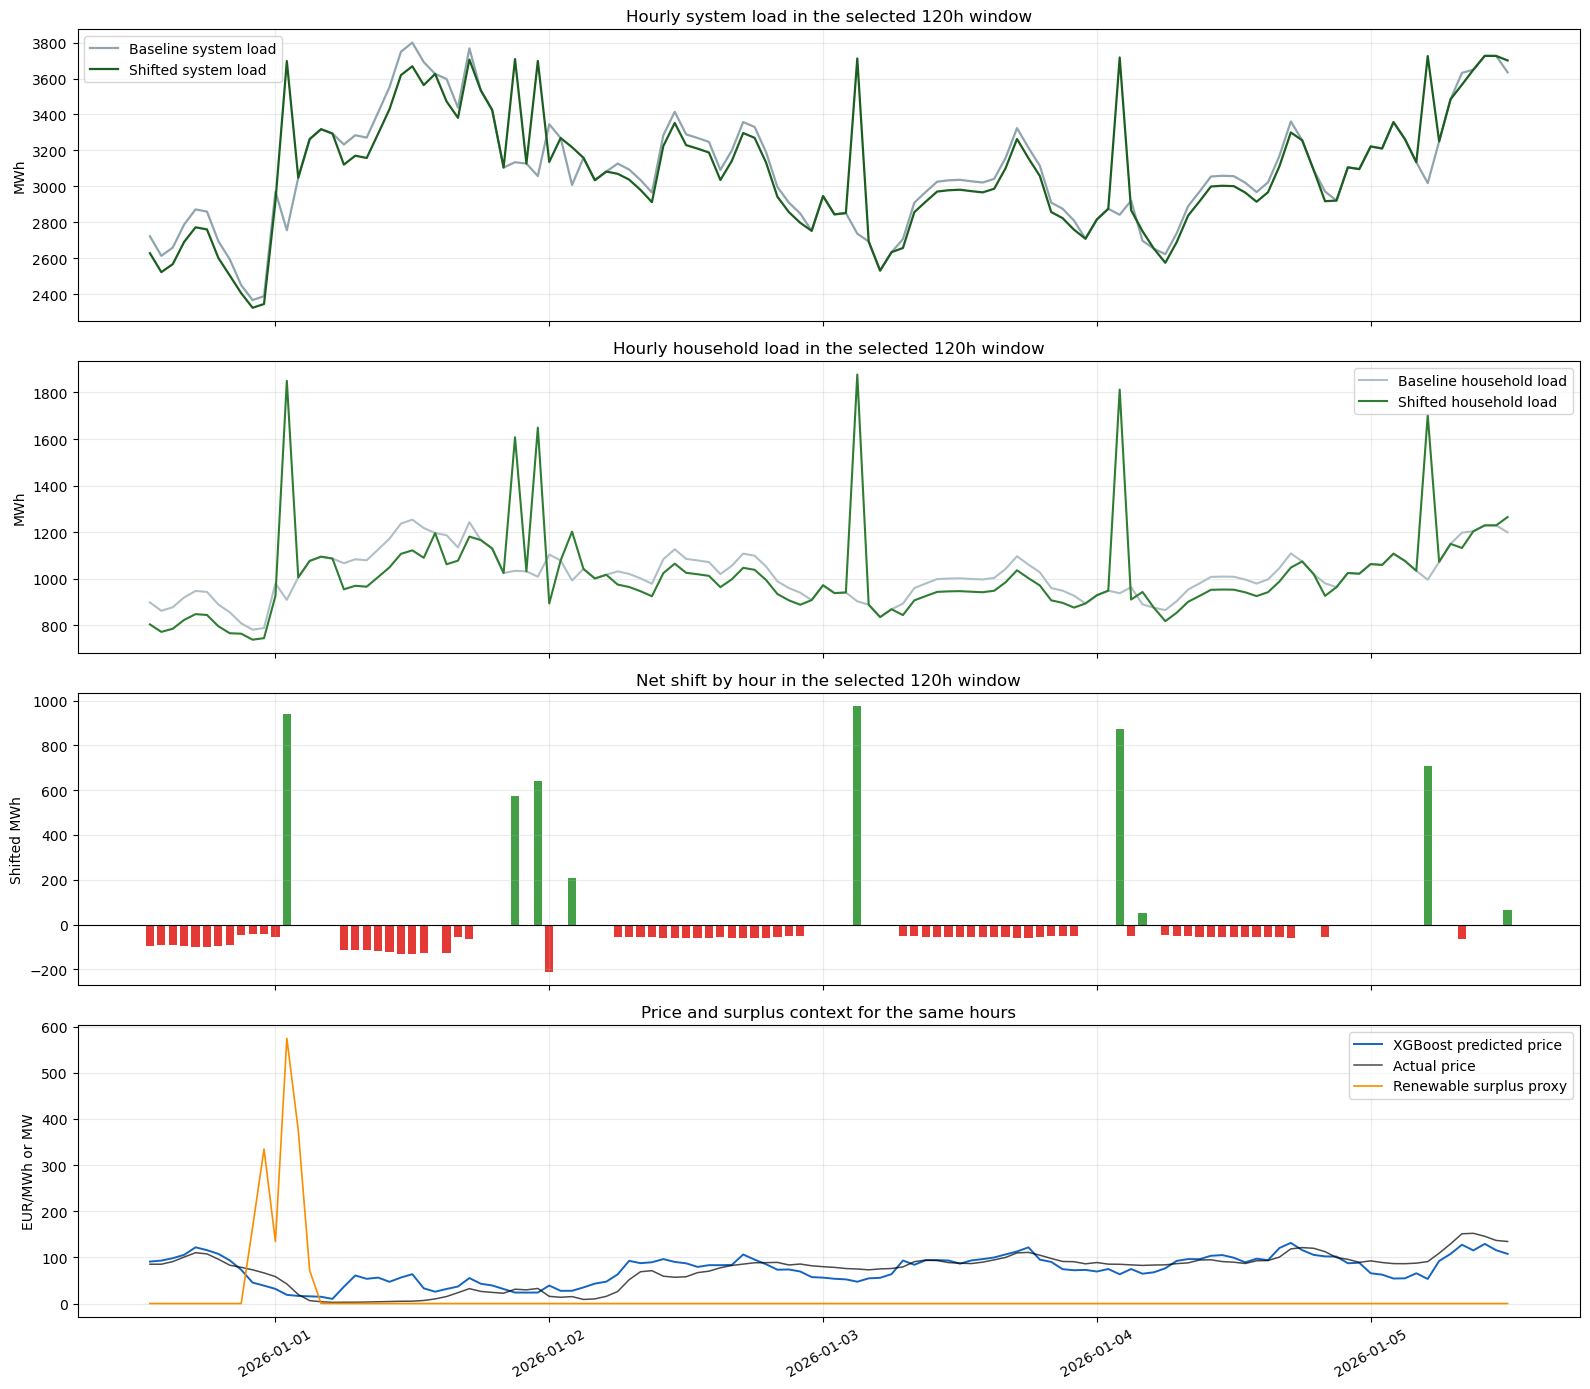

In [47]:
detail_df = prototype_df.copy()
detail_df["net_shift_mwh"] = detail_df["shifted_system_load_mwh"] - detail_df["system_load_mwh"]

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

axes[0].plot(detail_df["target_time"], detail_df["system_load_mwh"], label="Baseline system load", color="#90A4AE", linewidth=1.6)
axes[0].plot(detail_df["target_time"], detail_df["shifted_system_load_mwh"], label="Shifted system load", color="#1B5E20", linewidth=1.6)
axes[0].set_title("Hourly system load in the selected 120h window")
axes[0].set_ylabel("MWh")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(detail_df["target_time"], detail_df["household_load_mwh"], label="Baseline household load", color="#B0BEC5", linewidth=1.5)
axes[1].plot(detail_df["target_time"], detail_df["shifted_household_load_mwh"], label="Shifted household load", color="#2E7D32", linewidth=1.5)
axes[1].set_title("Hourly household load in the selected 120h window")
axes[1].set_ylabel("MWh")
axes[1].grid(alpha=0.25)
axes[1].legend()

bar_colors = np.where(detail_df["net_shift_mwh"] >= 0, "#43A047", "#E53935")
axes[2].bar(detail_df["target_time"], detail_df["net_shift_mwh"], color=bar_colors, width=0.03)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Net shift by hour in the selected 120h window")
axes[2].set_ylabel("Shifted MWh")
axes[2].grid(alpha=0.25)

axes[3].plot(detail_df["target_time"], detail_df["predicted"], label="XGBoost predicted price", color="#1565C0", linewidth=1.4)
axes[3].plot(detail_df["target_time"], detail_df["DayAheadPriceEUR"], label="Actual price", color="black", linewidth=1.1, alpha=0.7)
axes[3].plot(detail_df["target_time"], detail_df["surplus_proxy_mw"], label="Renewable surplus proxy", color="#FB8C00", linewidth=1.2)
axes[3].set_title("Price and surplus context for the same hours")
axes[3].set_ylabel("EUR/MWh or MW")
axes[3].grid(alpha=0.25)
axes[3].legend()

plt.xticks(rotation=30)
plt.tight_layout()


In [48]:
rolling_hour_pattern = rolling_backtest_df.copy()

annual_issue_times = daily_issue_times.tail(ANNUAL_HEATMAP_DAILY_ISSUES).reset_index(drop=True)
annual_non_overlapping_issue_times = annual_issue_times.iloc[::5].reset_index(drop=True)

annual_profiles = []
annual_shift_events = []

for issue_time in annual_non_overlapping_issue_times:
    annual_window_df = assemble_window_for_issue_time(
        issue_time=issue_time,
        preds=preds,
        system_load=system_load,
        renewable_supply=renewable_supply,
        household_share_of_system=HOUSEHOLD_SHARE_OF_SYSTEM,
        segment_assumptions=SEGMENT_ASSUMPTIONS,
    )
    annual_profile_df, annual_shifts_df = build_shift_plan(annual_window_df, SEGMENT_ASSUMPTIONS, DECISION_WEIGHTS)
    annual_profile_df = annual_profile_df.copy()
    annual_profile_df["issue_time"] = pd.Timestamp(issue_time)
    annual_profile_df["date"] = annual_profile_df["target_time"].dt.date
    annual_profile_df["hour"] = annual_profile_df["target_time"].dt.hour
    annual_profile_df["day_of_week"] = annual_profile_df["target_time"].dt.day_name()
    annual_profile_df["net_shift_mwh"] = annual_profile_df["shifted_system_load_mwh"] - annual_profile_df["system_load_mwh"]
    annual_profiles.append(annual_profile_df)
    if not annual_shifts_df.empty:
        annual_shifts_df = annual_shifts_df.copy()
        annual_shifts_df["issue_time"] = pd.Timestamp(issue_time)
        annual_shift_events.append(annual_shifts_df)

annual_profiles_df = pd.concat(annual_profiles, ignore_index=True)
annual_shift_events_df = pd.concat(annual_shift_events, ignore_index=True) if annual_shift_events else pd.DataFrame()

display(
    pd.Series(
        {
            "annual_daily_issue_times_available": int(len(annual_issue_times)),
            "annual_non_overlapping_120h_windows": int(len(annual_non_overlapping_issue_times)),
            "annual_profile_hours": int(len(annual_profiles_df)),
            "annual_start": str(annual_profiles_df["target_time"].min()),
            "annual_end": str(annual_profiles_df["target_time"].max()),
        }
    ).to_frame("value")
)


,value
annual_daily_issue_times_available,365
annual_non_overlapping_120h_windows,73
annual_profile_hours,8760
annual_start,2024-12-27 13:00:00
annual_end,2026-01-01 12:00:00


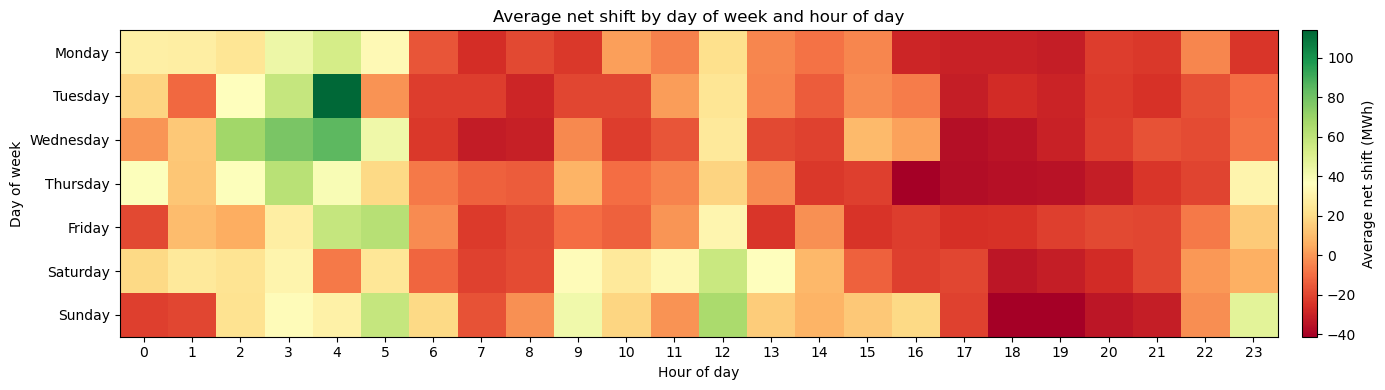

In [49]:
dow_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

net_shift_heatmap = (
    annual_profiles_df.groupby(["day_of_week", "hour"], as_index=False)["net_shift_mwh"]
    .mean()
    .assign(day_of_week=lambda df: pd.Categorical(df["day_of_week"], categories=dow_order, ordered=True))
    .sort_values(["day_of_week", "hour"])
    .pivot(index="day_of_week", columns="hour", values="net_shift_mwh")
)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(net_shift_heatmap.to_numpy(), aspect="auto", cmap="RdYlGn", interpolation="nearest")
ax.set_title("Average net shift by day of week and hour of day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Day of week")
ax.set_xticks(np.arange(24))
ax.set_yticks(np.arange(len(net_shift_heatmap.index)))
ax.set_yticklabels(net_shift_heatmap.index.tolist())
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Average net shift (MWh)")
plt.tight_layout()


## Yearly Before/After Heatmaps

To make the heatmaps interpretable, the notebook uses a continuous non-overlapping annual sample built from `120h` windows spaced `5` days apart. That gives a clean year-like hourly panel without double-counting overlapping forecast horizons.


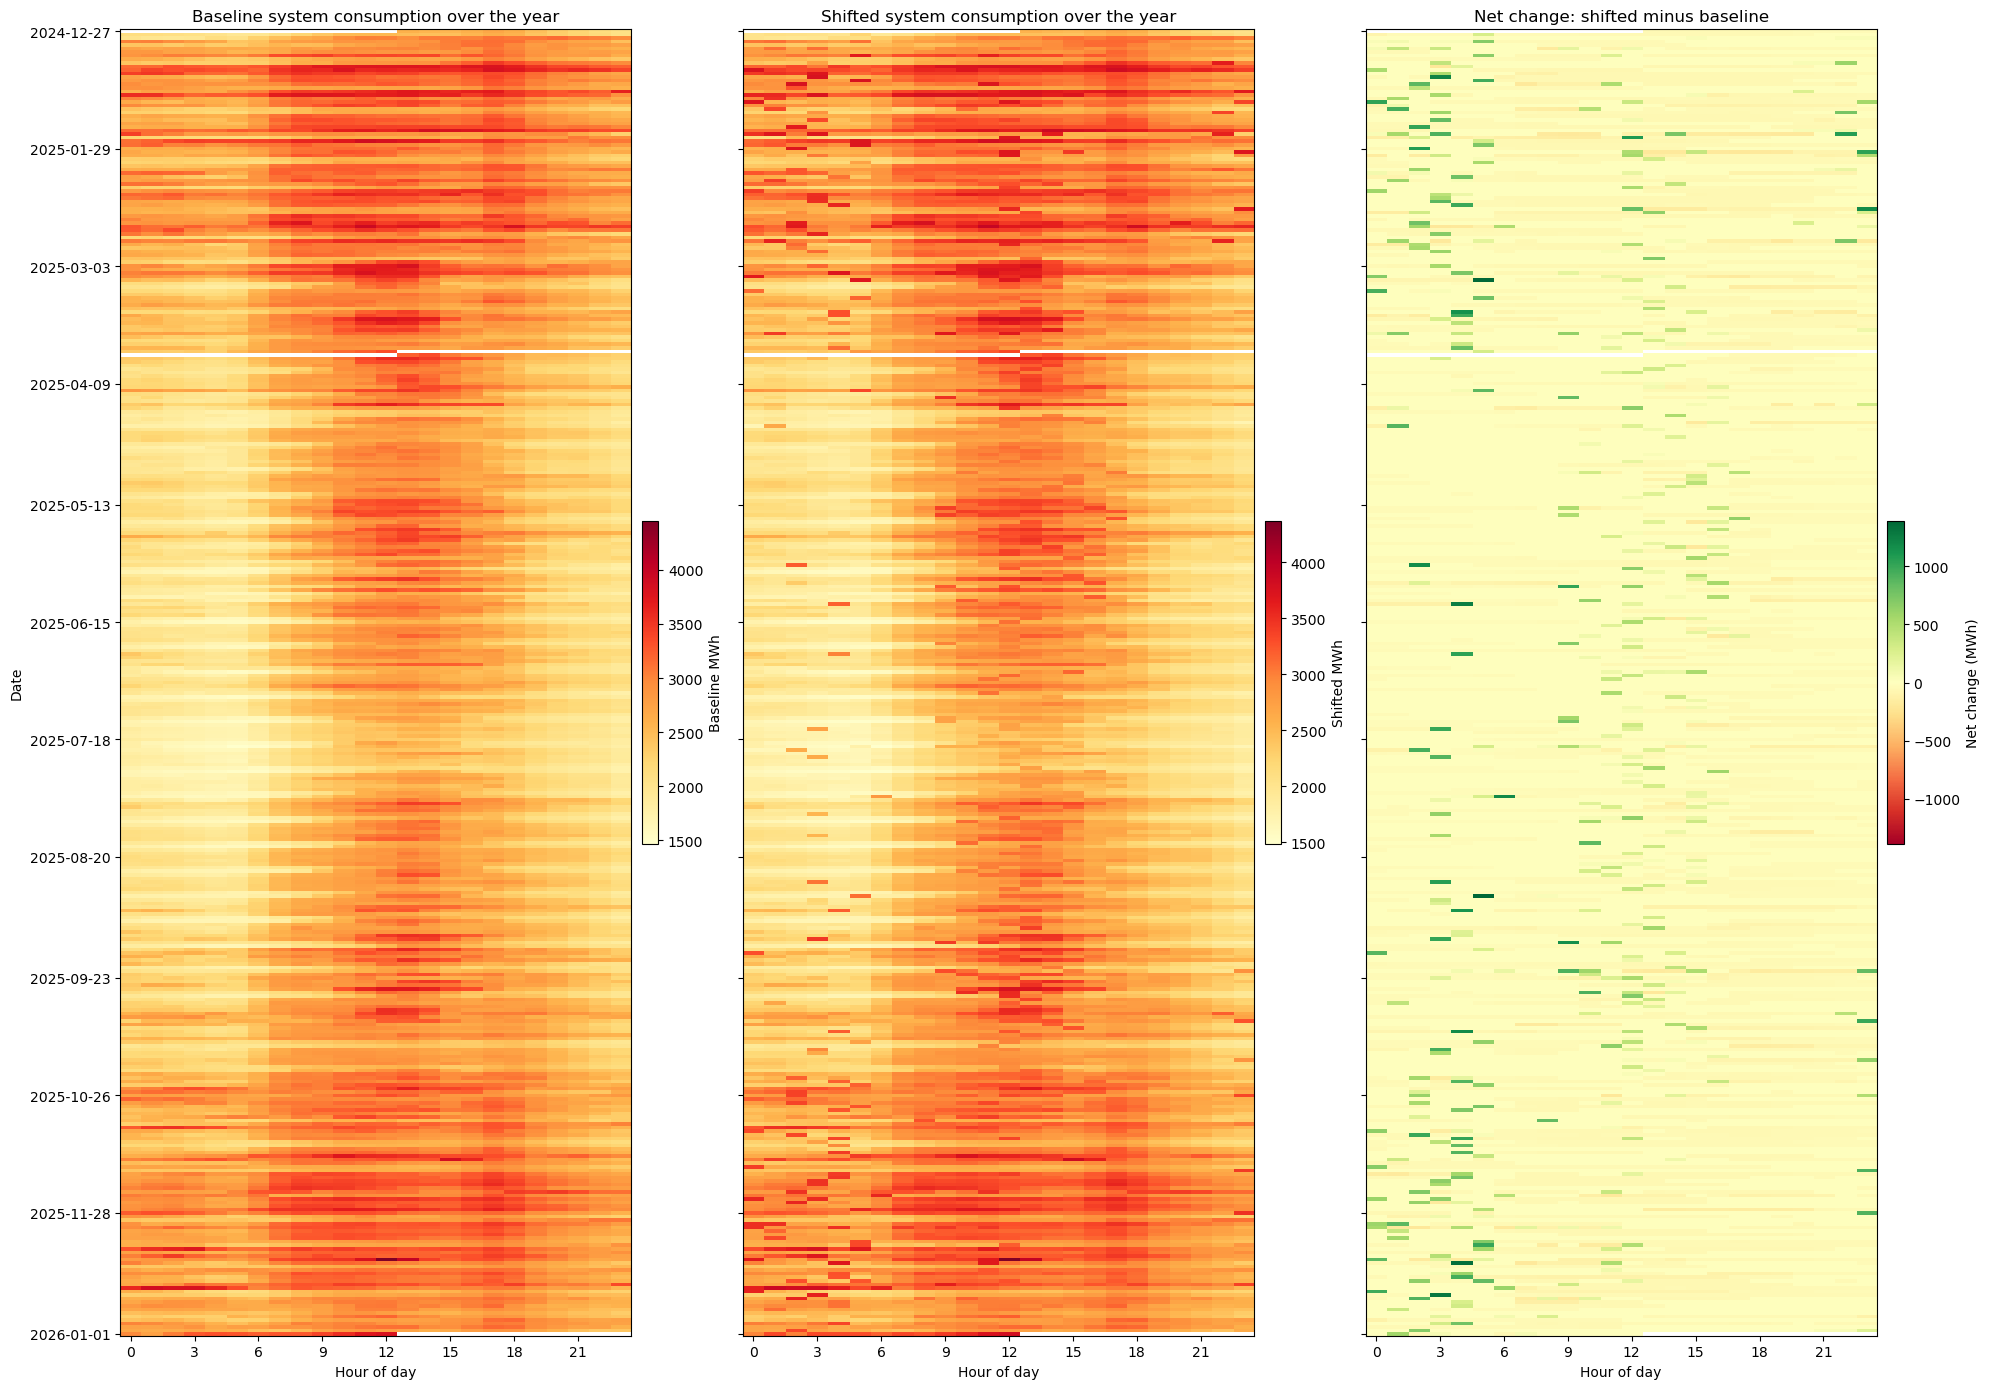

In [50]:
baseline_year_heatmap = (
    annual_profiles_df.pivot(index="date", columns="hour", values="system_load_mwh")
    .sort_index()
)
shifted_year_heatmap = (
    annual_profiles_df.pivot(index="date", columns="hour", values="shifted_system_load_mwh")
    .sort_index()
)
difference_year_heatmap = shifted_year_heatmap - baseline_year_heatmap

fig, axes = plt.subplots(1, 3, figsize=(20, 14), sharey=True)

im0 = axes[0].imshow(baseline_year_heatmap.to_numpy(), aspect="auto", cmap="YlOrRd", interpolation="nearest")
axes[0].set_title("Baseline system consumption over the year")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Date")
axes[0].set_xticks(np.arange(0, 24, 3))

im1 = axes[1].imshow(shifted_year_heatmap.to_numpy(), aspect="auto", cmap="YlOrRd", interpolation="nearest")
axes[1].set_title("Shifted system consumption over the year")
axes[1].set_xlabel("Hour of day")
axes[1].set_xticks(np.arange(0, 24, 3))

max_abs_diff = np.nanmax(np.abs(difference_year_heatmap.to_numpy()))
im2 = axes[2].imshow(
    difference_year_heatmap.to_numpy(),
    aspect="auto",
    cmap="RdYlGn",
    interpolation="nearest",
    vmin=-max_abs_diff,
    vmax=max_abs_diff,
)
axes[2].set_title("Net change: shifted minus baseline")
axes[2].set_xlabel("Hour of day")
axes[2].set_xticks(np.arange(0, 24, 3))

date_tick_positions = np.linspace(0, len(baseline_year_heatmap.index) - 1, 12, dtype=int)
axes[0].set_yticks(date_tick_positions)
axes[0].set_yticklabels([str(baseline_year_heatmap.index[i]) for i in date_tick_positions])

cbar0 = fig.colorbar(im0, ax=axes[0], fraction=0.03, pad=0.02)
cbar0.set_label("Baseline MWh")
cbar1 = fig.colorbar(im1, ax=axes[1], fraction=0.03, pad=0.02)
cbar1.set_label("Shifted MWh")
cbar2 = fig.colorbar(im2, ax=axes[2], fraction=0.03, pad=0.02)
cbar2.set_label("Net change (MWh)")

plt.tight_layout()


## Next Prototype Steps

This version now includes:
- one fully inspectable 120-hour prototype window
- explicit shifted MWh and shifted-share metrics
- a daily rolling backtest sample
- a non-overlapping horizon summary for clean aggregate consumption shares

The next improvements should be:

1. replace the heuristic with an optimization model
2. use horizon-specific XGBoost residual distributions for forecast uncertainty
3. make EV and thermal segments deadline-based instead of using one generic shift rule
4. add formal grid stress metrics and supplier-side surplus absorption metrics across the full sample
5. compare multiple scenario settings for household shares and flexibility assumptions
